In [1]:
pip install -U kaleido

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


# Imports

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
import plotly.express as px

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, f1_score, confusion_matrix, precision_recall_curve, precision_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

In [3]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [4]:
df_train.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [5]:
df_train.drop(df_train.columns[0], axis=1, inplace=True)
df_test.drop(df_test.columns[0], axis=1, inplace=True)

In [6]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [7]:
#data types
print(df_train.dtypes)

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


In [8]:
print(df_train.isnull().sum())
print(df_test.isnull().sum())

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop       

In [9]:
print(df_train.shape)
print(f"Duplicate rows: {df_train.duplicated().sum()}")

print(df_test.shape)
print(f"Duplicate rows: {df_test.duplicated().sum()}")

(1296675, 22)
Duplicate rows: 0
(555719, 22)
Duplicate rows: 0


In [10]:
#check for class imbalance
print(df_train['is_fraud'].value_counts())
print(df_train['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


# Feature Engineering

In [11]:
#some light feature eng
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['dob'] = pd.to_datetime(df_train['dob'])

df_train['trans_hour'] = df_train['trans_date_trans_time'].dt.hour
df_train['trans_dayofweek'] = df_train['trans_date_trans_time'].dt.dayofweek
df_train['trans_month'] = df_train['trans_date_trans_time'].dt.month
df_train['age'] = (df_train['trans_date_trans_time'] - df_train['dob']).dt.days // 365

print(df_train[['trans_hour', 'trans_dayofweek', 'trans_month', 'age']].head())

#have to do it for test too
df_test['trans_date_trans_time'] = pd.to_datetime(df_test['trans_date_trans_time'])
df_test['dob'] = pd.to_datetime(df_test['dob'])

df_test['trans_hour'] = df_test['trans_date_trans_time'].dt.hour
df_test['trans_dayofweek'] = df_test['trans_date_trans_time'].dt.dayofweek
df_test['trans_month'] = df_test['trans_date_trans_time'].dt.month
df_test['age'] = (df_test['trans_date_trans_time'] - df_test['dob']).dt.days // 365

print(df_test[['trans_hour', 'trans_dayofweek', 'trans_month', 'age']].head())

   trans_hour  trans_dayofweek  trans_month  age
0           0                1            1   30
1           0                1            1   40
2           0                1            1   56
3           0                1            1   52
4           0                1            1   32
   trans_hour  trans_dayofweek  trans_month  age
0          12                6            6   52
1          12                6            6   30
2          12                6            6   49
3          12                6            6   32
4          12                6            6   65


In [12]:
df_train.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_dayofweek,trans_month,age
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1,1,30
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1,1,40
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1,1,56
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1,1,52
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1,1,32


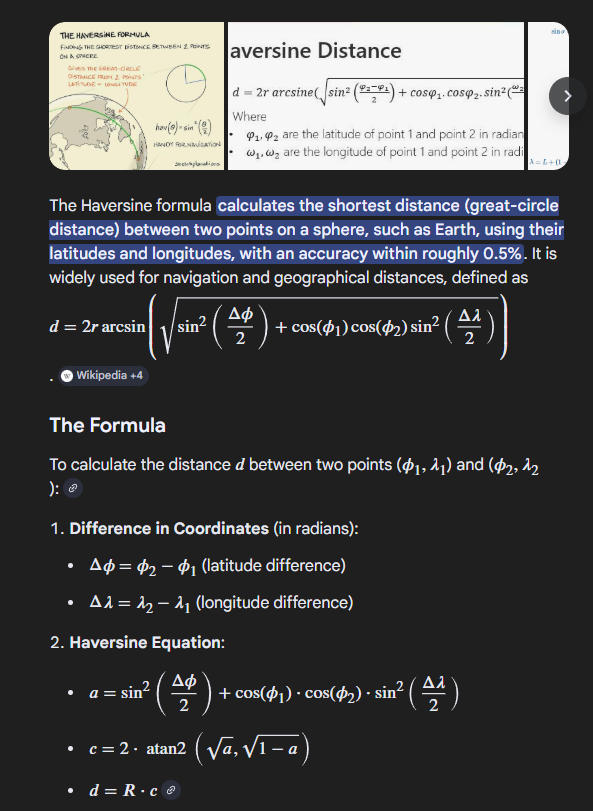

In [13]:
#more feature engineering
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a)) #guys remember that atan can be written using arcsin

df_train['distance_km'] = haversine_distance(
    df_train['lat'], df_train['long'], df_train['merch_lat'], df_train['merch_long']
)

df_test['distance_km'] = haversine_distance(
    df_test['lat'], df_test['long'], df_test['merch_lat'], df_test['merch_long']
)

print(df_train.groupby('is_fraud')['distance_km'].mean())
#rough this means that distance is not a strong signal for it which I was hoping that it would be.

is_fraud
0    76.113756
1    76.268330
Name: distance_km, dtype: float64


# EDA

In [14]:
df_train['category_name'] = df_train['category'].copy()

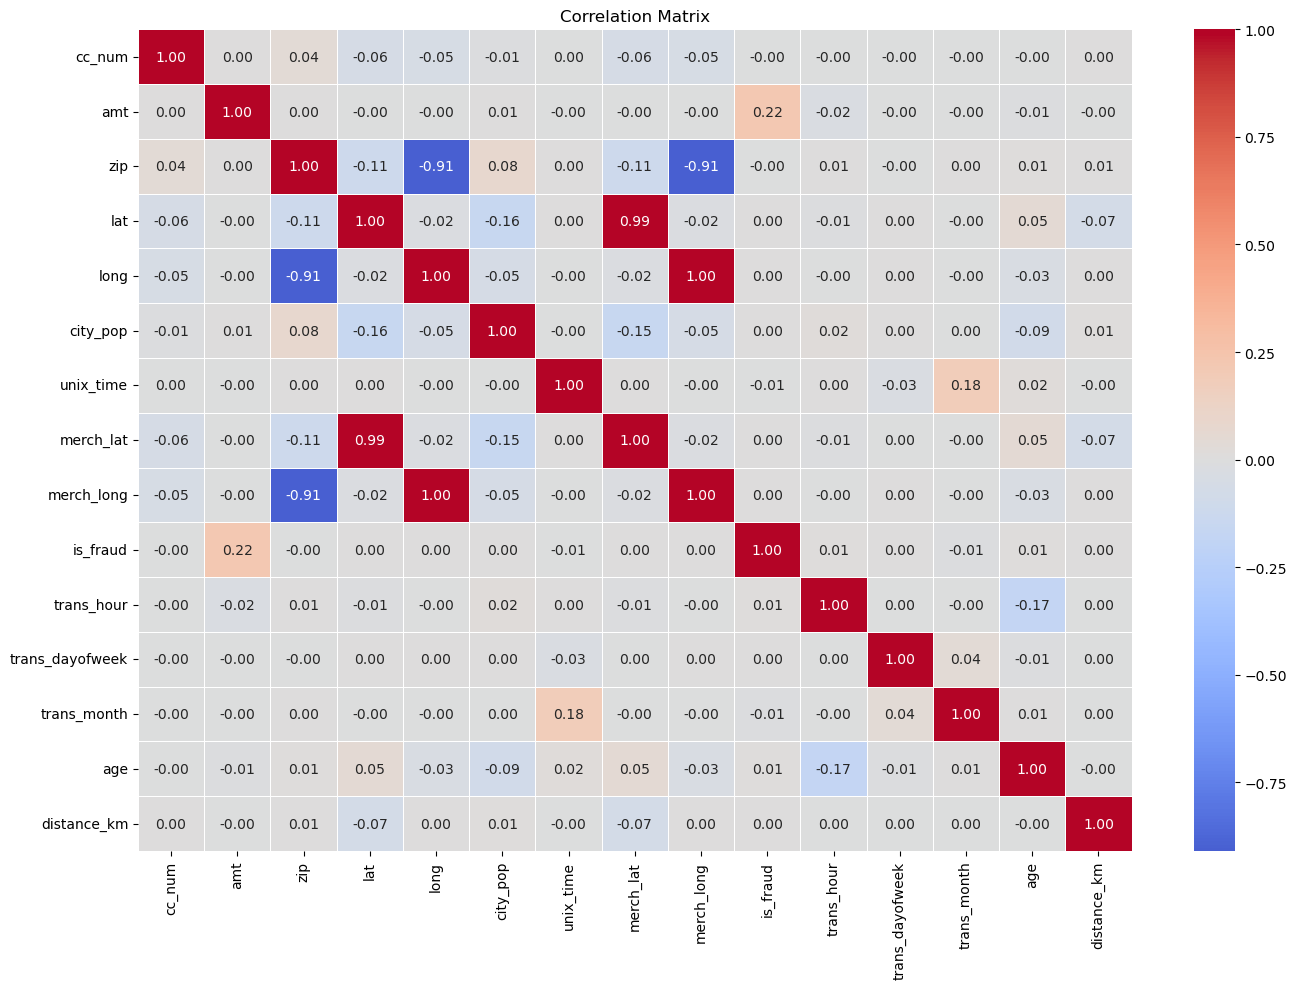

In [15]:
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()

corr = df_train[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

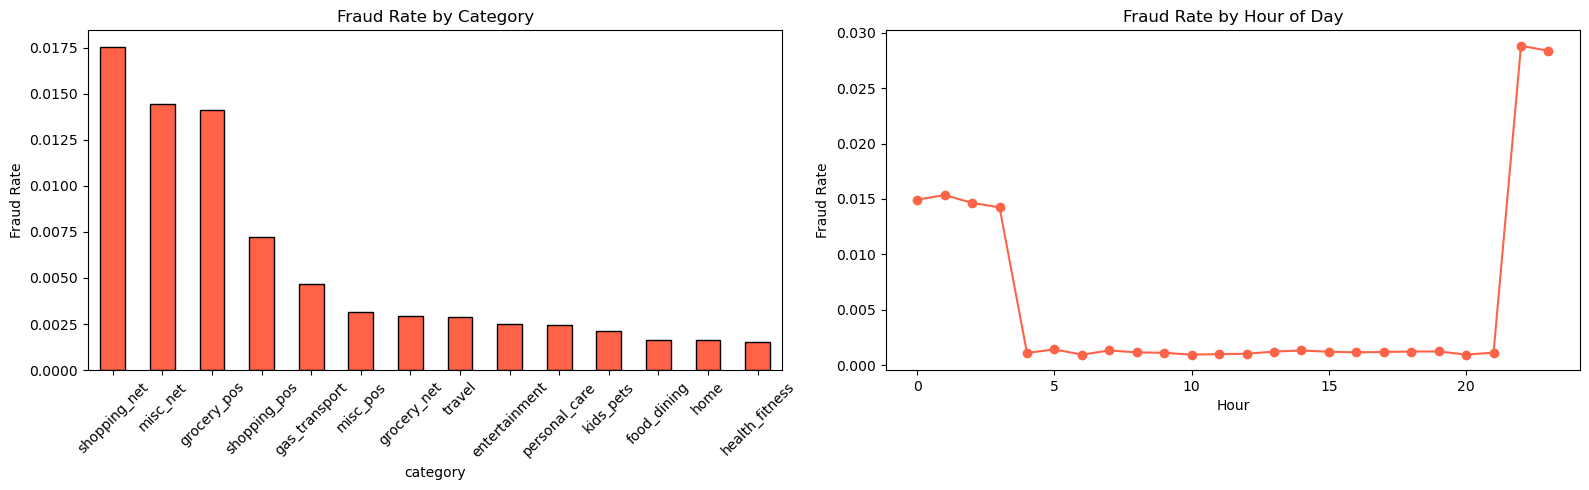

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_train.groupby('category')['is_fraud'].mean().sort_values(ascending=False).plot.bar(
    ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Fraud Rate by Category')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=45)

df_train.groupby('trans_hour')['is_fraud'].mean().plot(
    ax=axes[1], marker='o', color='tomato')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

C:\Users\Tanji\AppData\Local\Temp\ipykernel_18528\591274703.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_by_age = df_plot.groupby('age_group')['is_fraud'].mean() * 100  # df_plot not df_train
C:\Users\Tanji\AppData\Local\Temp\ipykernel_18528\591274703.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_count_by_age = df_plot[df_plot['is_fraud']==1].groupby('age_group').size()  # df_plot not df_train


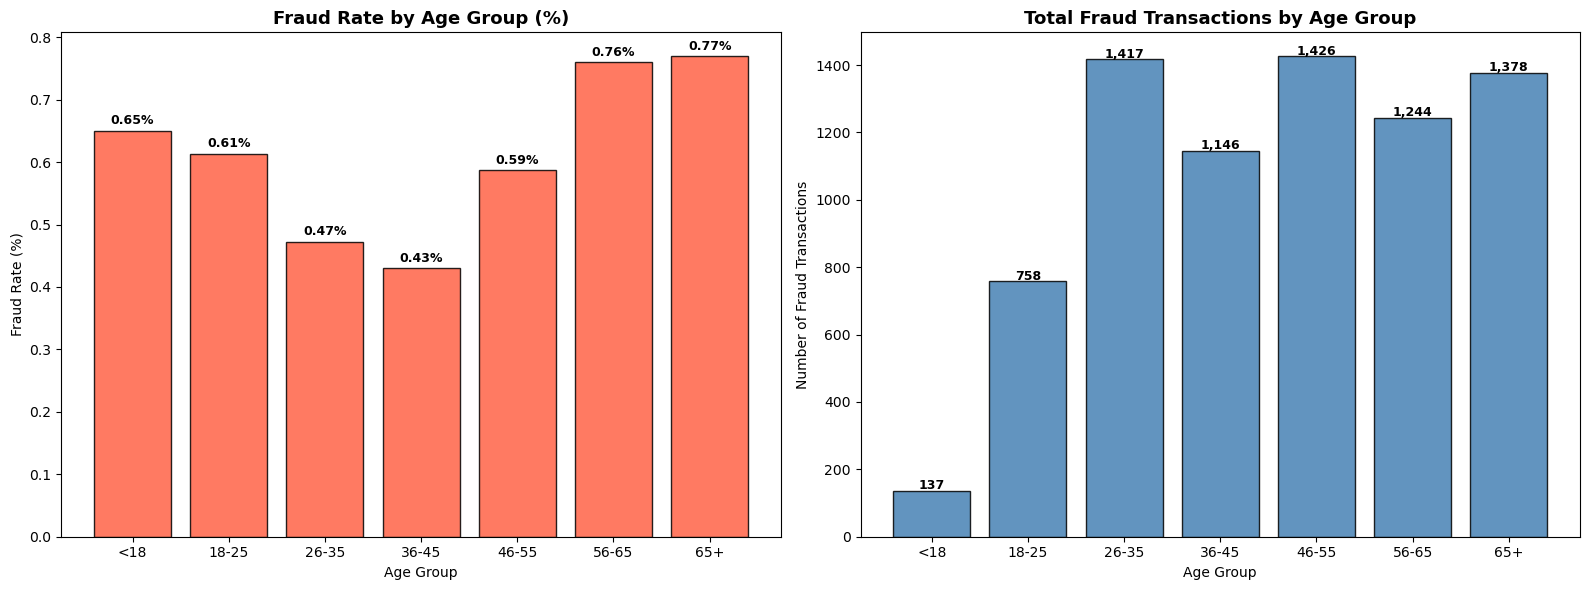

In [17]:
# create age bins
df_plot = df_train.copy()
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
df_plot['age_group'] = pd.cut(df_plot['age'], bins=bins, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# fraud rate by age group
fraud_by_age = df_plot.groupby('age_group')['is_fraud'].mean() * 100  # df_plot not df_train
axes[0].bar(fraud_by_age.index, fraud_by_age.values,
            color='tomato', edgecolor='black', alpha=0.85)
axes[0].set_title('Fraud Rate by Age Group (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Fraud Rate (%)')
for i, v in enumerate(fraud_by_age.values):
    axes[0].text(i, v + 0.01, f'{v:.2f}%', ha='center', fontsize=9, fontweight='bold')

# total fraud transactions by age group
fraud_count_by_age = df_plot[df_plot['is_fraud']==1].groupby('age_group').size()  # df_plot not df_train
axes[1].bar(fraud_count_by_age.index, fraud_count_by_age.values,
            color='steelblue', edgecolor='black', alpha=0.85)
axes[1].set_title('Total Fraud Transactions by Age Group', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Fraud Transactions')
for i, v in enumerate(fraud_count_by_age.values):
    axes[1].text(i, v + 5, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

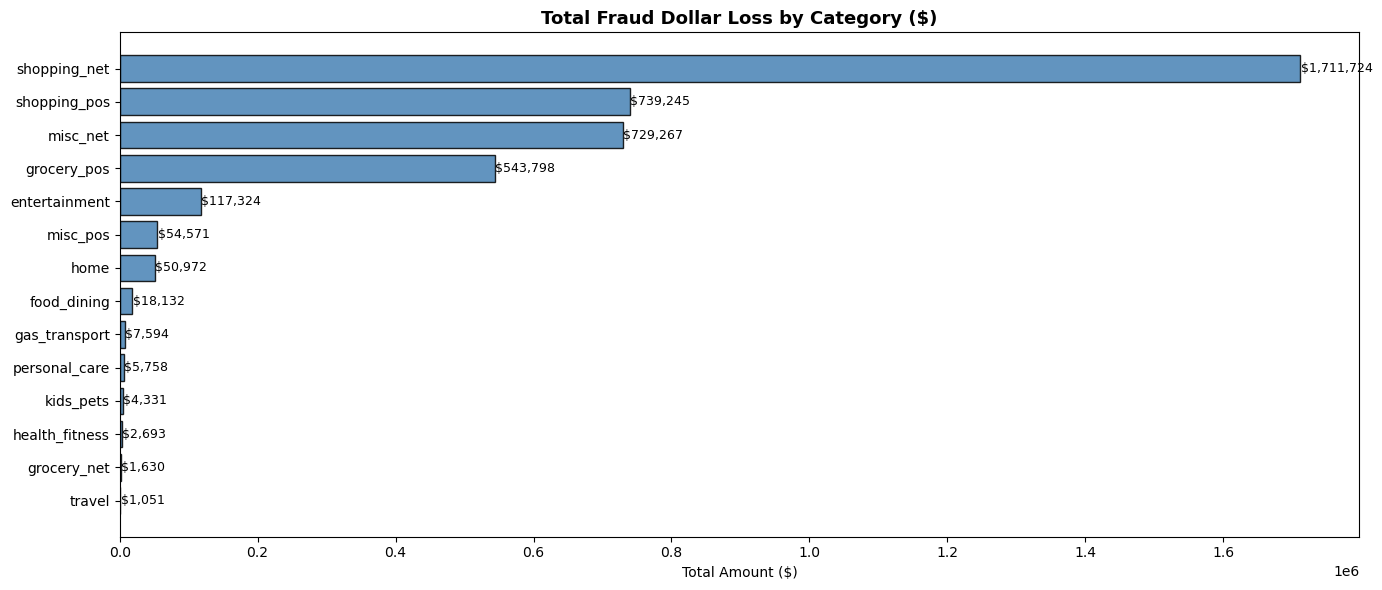

In [18]:
df_plot_cat = df_train.copy()
df_plot_cat['category_name'] = df_plot_cat['category'].copy()

fraud_amt = df_plot_cat[df_plot_cat['is_fraud']==1].groupby('category_name')['amt'].sum().sort_values(ascending=False)

plt.figure(figsize=(14, 6))
bars = plt.barh(fraud_amt.index, fraud_amt.values,
                color='steelblue', edgecolor='black', alpha=0.85)
plt.title('Total Fraud Dollar Loss by Category ($)', fontsize=13, fontweight='bold')
plt.xlabel('Total Amount ($)')
plt.gca().invert_yaxis()
for bar in bars:
    plt.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'${bar.get_width():,.0f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

In [19]:
state_names = sorted(pd.read_csv('train.csv')['state'].unique())

fraud_by_state = df_train.groupby('state').agg(
    fraud_rate=('is_fraud', 'mean'),
    count=('is_fraud', 'count')
).reset_index()

# filter out states with fewer than 500 transactions since not statistically meaningful
fraud_by_state = fraud_by_state[fraud_by_state['count'] >= 500]
fraud_by_state['fraud_rate'] = fraud_by_state['fraud_rate'] * 100
# removed the .map(state_mapping) line — state is already a string abbreviation here

fig = px.choropleth(
    fraud_by_state,
    locations='state',
    locationmode='USA-states',
    color='fraud_rate',
    scope='usa',
    color_continuous_scale='Reds',
    title='Fraud Rate by State (%) — states with 500+ transactions',
    labels={'fraud_rate': 'Fraud Rate (%)'}
)
fig.show()

C:\Users\Tanji\AppData\Roaming\Python\Python312\site-packages\kaleido\_sync_server.py:11: UserWarning:




This means that static image generation (e.g. `fig.write_image()`) will not work.

Please upgrade Plotly to version 6.1.1 or greater, or downgrade Kaleido to version 0.2.1.




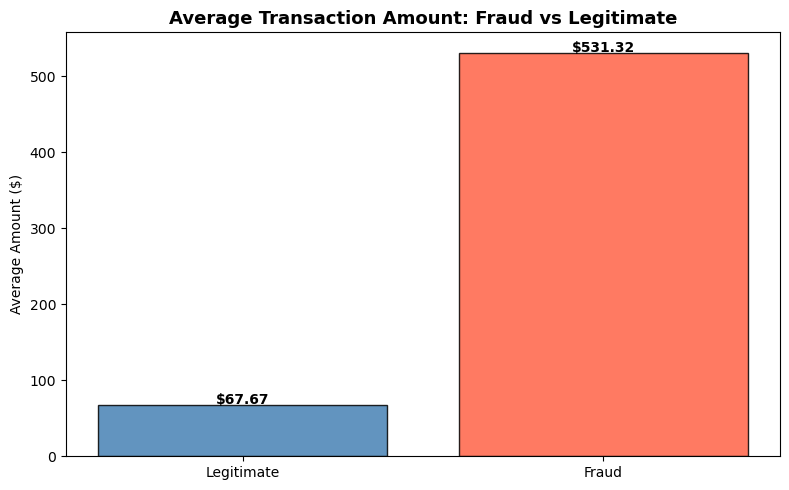

In [20]:
avg_amt = df_train.groupby('is_fraud')['amt'].mean()

plt.figure(figsize=(8, 5))
bars = plt.bar(['Legitimate', 'Fraud'], avg_amt.values,
               color=['steelblue', 'tomato'], edgecolor='black', alpha=0.85)
plt.title('Average Transaction Amount: Fraud vs Legitimate', fontsize=13, fontweight='bold')
plt.ylabel('Average Amount ($)')
for i, v in enumerate(avg_amt.values):
    plt.text(i, v + 1, f'${v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [21]:
print(f"Unique cities: {df_train['city'].nunique()}")
print(f"Unique states: {df_train['state'].nunique()}")

Unique cities: 894
Unique states: 51


# Preprocessing Before Model & Feature Engineering

In [22]:
cols_to_drop = [
    'cc_num', # ID, zero correlation with fraud ngl
    'trans_num', # type of ID it has no signal
    'first', 'last', 'street', #personal info I dont think this has any yse
    'unix_time', # 0.99 corr with trans_month it is redundant
    'dob', # extracted age already
    'trans_date_trans_time', # extracted hour, day, month already
    'lat', 'long', # 0.99 corr with merch_lat/long, captured in distance_km
    'merch_lat', 'merch_long',
    'zip', # -0.91 corr with long, redundant location info
    'merchant',# too many unique values, high cardinality might KEEEP??? later
    'job', 'city', 'category_name' #no signal, I just use state, city might blow up feature space we could try with this alter tho
]

df_train.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=cols_to_drop, inplace=True, errors='ignore')

print(df_train.columns.tolist())
print(df_train.shape)

['category', 'amt', 'gender', 'state', 'city_pop', 'is_fraud', 'trans_hour', 'trans_dayofweek', 'trans_month', 'age', 'distance_km']
(1296675, 11)


In [23]:
labelencoderrr = LabelEncoder()

for col in ['category', 'gender', 'state']:
    df_train[col] = labelencoderrr.fit_transform(df_train[col])
    df_test[col] = labelencoderrr.transform(df_test[col]) #you only transform on test, keep things consistent. If the data appears in different order then it transforms differently if you fit again

print(df_train.head())
print(df_train.dtypes)

   category     amt  gender  state  city_pop  is_fraud  trans_hour  \
0         8    4.97       0     27      3495         0           0   
1         4  107.23       0     47       149         0           0   
2         0  220.11       1     13      4154         0           0   
3         2   45.00       1     26      1939         0           0   
4         9   41.96       1     45        99         0           0   

   trans_dayofweek  trans_month  age  distance_km  
0                1            1   30    78.597568  
1                1            1   40    30.212176  
2                1            1   56   108.206083  
3                1            1   52    95.673231  
4                1            1   32    77.556744  
category             int32
amt                float64
gender               int32
state                int32
city_pop             int64
is_fraud             int64
trans_hour           int32
trans_dayofweek      int32
trans_month          int32
age                  int

In [24]:
X_train = df_train.drop(columns=['is_fraud'])
y_train = df_train['is_fraud']

X_test = df_test.drop(columns=['is_fraud'])
y_test = df_test['is_fraud']

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")

X_train: (1296675, 10)
X_test: (555719, 10)

y_train distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

y_test distribution:
is_fraud
0    553574
1      2145
Name: count, dtype: int64


In [25]:
print(X_train.select_dtypes(include='object').columns.tolist())
print(X_train.dtypes)

[]
category             int32
amt                float64
gender               int32
state                int32
city_pop             int64
trans_hour           int32
trans_dayofweek      int32
trans_month          int32
age                  int64
distance_km        float64
dtype: object


In [26]:
smote = SMOTE(random_state=67) #67 meme fr
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Before SMOTE: {0: 1289169, 1: 7506}
After SMOTE: {0: 1289169, 1: 1289169}


hurray everything equal yall can get to modelling rn

# Models

## Logistic Regression Baseline

In [27]:
# scaling the features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(random_state=67, max_iter=1000, n_jobs=-1)
lr.fit(X_train_scaled, y_train_resampled)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98    553574
           1       0.06      0.74      0.11      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.97    555719



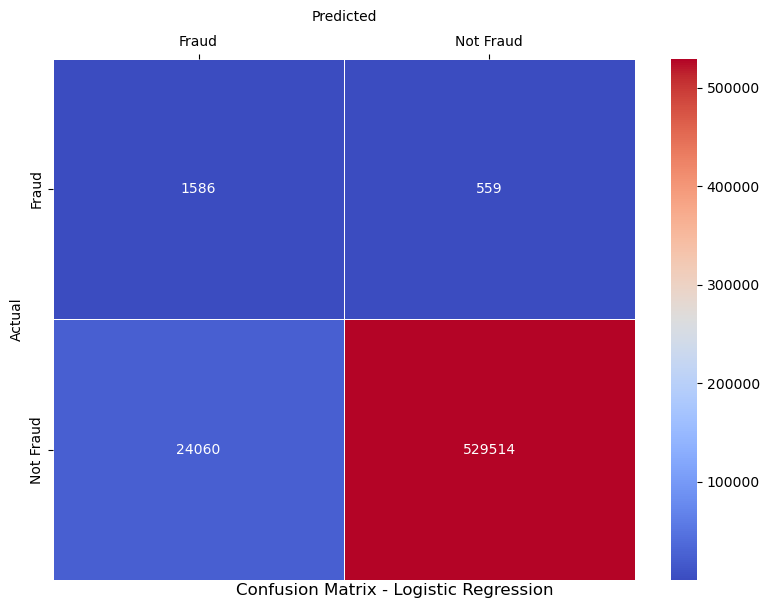

In [28]:
cm_lr = confusion_matrix(y_test, y_pred_lr, labels=[1, 0])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lr, cmap='coolwarm', annot=True, fmt='d',
            xticklabels=['Fraud', 'Not Fraud'],
            yticklabels=['Fraud', 'Not Fraud'],
            linewidths=0.5, ax=ax)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual')

fig.text(0.5, 0.00, 'Confusion Matrix - Logistic Regression', 
         ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## Decision Tree Baseline

In [29]:
#baseline decision trees
clf_dt = DecisionTreeClassifier(
    criterion='entropy',
    random_state=67,
    class_weight='balanced'
)

clf_dt.fit(X_train_resampled, y_train_resampled)
y_pred_dt = clf_dt.predict(X_test)

print("Decision Tree:")
print(classification_report(y_test, y_pred_dt))

Decision Tree:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.26      0.81      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.63      0.90      0.69    555719
weighted avg       1.00      0.99      0.99    555719



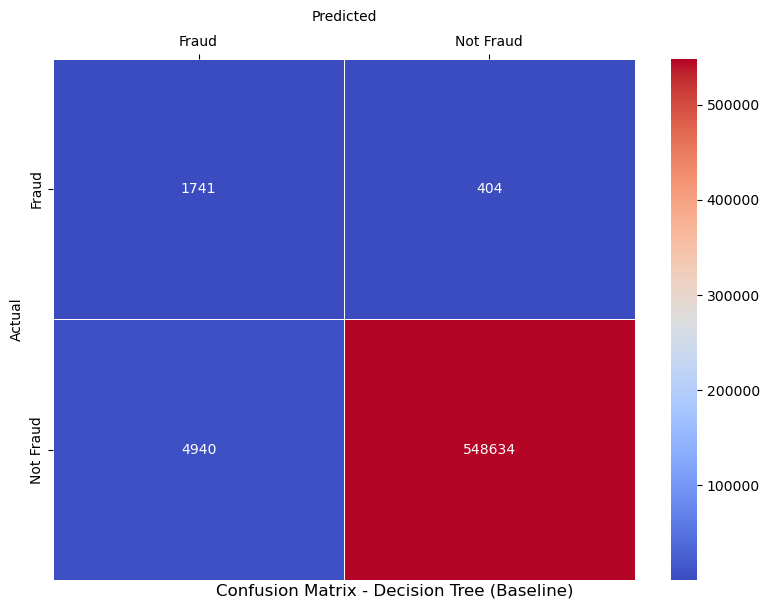

In [30]:
cm_dt = confusion_matrix(y_test, y_pred_dt, labels=[1, 0])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_dt, cmap='coolwarm', annot=True, fmt='d',
            xticklabels=['Fraud', 'Not Fraud'],
            yticklabels=['Fraud', 'Not Fraud'],
            linewidths=0.5, ax=ax)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual')

fig.text(0.5, 0.00, 'Confusion Matrix - Decision Tree (Baseline)',
         ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## Random Forest Baseline

In [31]:
# baseline random forest - no tuning yet
clf_rf = RandomForestClassifier(
    n_estimators=100,
    random_state=67,
    class_weight='balanced',
    n_jobs=-1
)

clf_rf.fit(X_train_resampled, y_train_resampled)
y_pred_rf = clf_rf.predict(X_test)

print("Random Forest:")
print(classification_report(y_test, y_pred_rf))

Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.60      0.82      0.69      2145

    accuracy                           1.00    555719
   macro avg       0.80      0.91      0.84    555719
weighted avg       1.00      1.00      1.00    555719



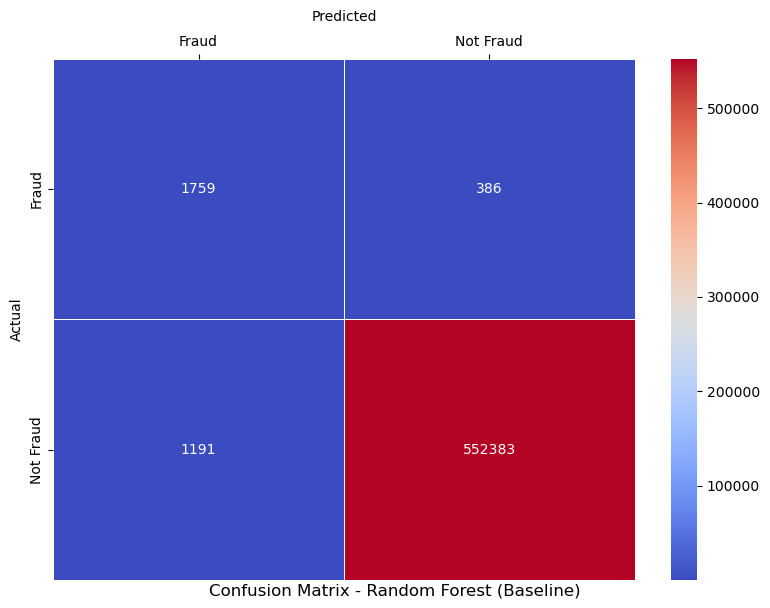

In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=[1, 0])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, cmap='coolwarm', annot=True, fmt='d',
            xticklabels=['Fraud', 'Not Fraud'],
            yticklabels=['Fraud', 'Not Fraud'],
            linewidths=0.5, ax=ax)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual')

fig.text(0.5, 0.00, 'Confusion Matrix - Random Forest (Baseline)',
         ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## Baseline model Comparison

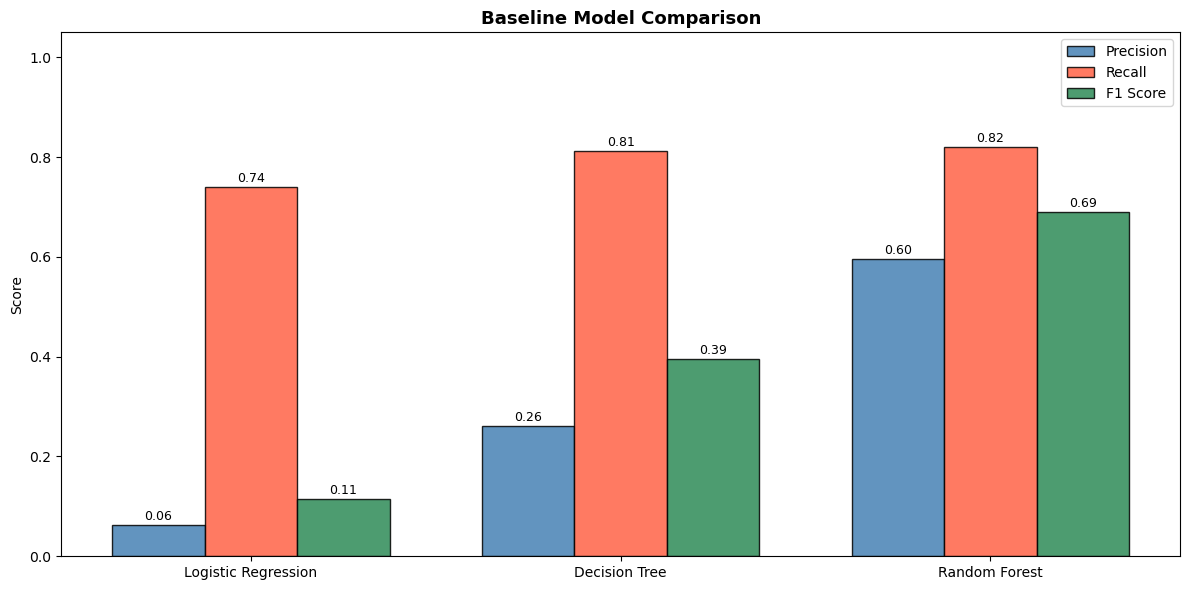

In [35]:
# comparing all 3 baseline models side by side

model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
preds = [y_pred_lr, y_pred_dt, y_pred_rf]

precision_scores = [precision_score(y_test, p) for p in preds]
recall_scores = [recall_score(y_test, p) for p in preds]
f1_scores = [f1_score(y_test, p) for p in preds]

x = np.arange(len(model_names))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width, precision_scores, width, label='Precision', color='steelblue', edgecolor='black', alpha=0.85)
ax.bar(x, recall_scores, width, label='Recall', color='tomato', edgecolor='black', alpha=0.85)
ax.bar(x + width, f1_scores, width, label='F1 Score',  color='seagreen',  edgecolor='black', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Baseline Model Comparison', fontsize=13, fontweight='bold')
ax.legend()

for i, (p, r, f) in enumerate(zip(precision_scores, recall_scores, f1_scores)):
    ax.text(i - width, p + 0.01, f'{p:.2f}', ha='center', fontsize=9)
    ax.text(i, r + 0.01, f'{r:.2f}', ha='center', fontsize=9)
    ax.text(i + width, f + 0.01, f'{f:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## Random Forest CV + Hyperparameter Tuning

In [36]:
# cross-validating random forest before tuning to check stability
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=67)

cv_scores = cross_val_score(
    clf_rf, X_train_resampled, y_train_resampled,
    cv=skf,
    scoring='f1'
)

print(f"CV F1 per fold: {cv_scores}")
print(f"Mean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

CV F1 per fold: [0.99797371 0.99787667 0.99791749 0.99799522 0.99801046]
Mean F1: 0.9980 (+/- 0.0001)


In [38]:
from sklearn.utils import resample

# sample 30% for tuning
X_tune, y_tune = resample(
    X_train_resampled, y_train_resampled,
    n_samples=int(len(X_train_resampled) * 0.3),
    stratify=y_train_resampled,
    random_state=67
)

print(f"Tuning on {X_tune.shape[0]} samples instead of {X_train_resampled.shape[0]}")

param_dist = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'n_estimators': [100, 200],
    'class_weight': ['balanced']
}

skf_tune = StratifiedKFold(n_splits=3, shuffle=True, random_state=67)

rf_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=67, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=20,
    cv=skf_tune,
    scoring='f1',
    random_state=67,
    n_jobs=-1
)

rf_search.fit(X_tune, y_tune)
print(f"Best params: {rf_search.best_params_}")
print(f"Best CV F1:  {rf_search.best_score_:.4f}")

Tuning on 773501 samples instead of 2578338
Best params: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None, 'class_weight': 'balanced'}
Best CV F1:  0.9935


In [39]:
# fit final model on full resampled data using best params from tuning
clf_rf_tuned = RandomForestClassifier(
    **rf_search.best_params_,
    random_state=67,
    n_jobs=-1
)

clf_rf_tuned.fit(X_train_resampled, y_train_resampled)
y_pred_rf_tuned = clf_rf_tuned.predict(X_test)

print("Random Forest (Tuned):")
print(classification_report(y_test, y_pred_rf_tuned))

Random Forest (Tuned):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.59      0.82      0.69      2145

    accuracy                           1.00    555719
   macro avg       0.80      0.91      0.84    555719
weighted avg       1.00      1.00      1.00    555719



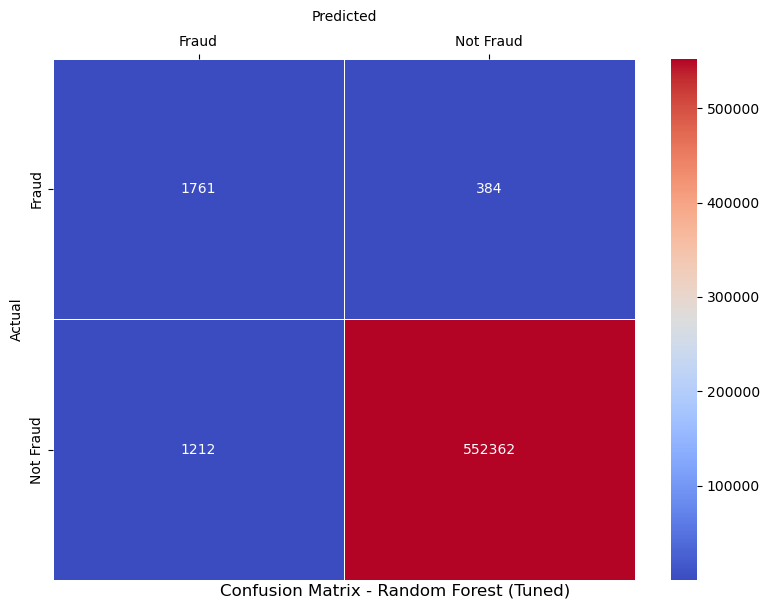

In [40]:
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned, labels=[1, 0])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf_tuned, cmap='coolwarm', annot=True, fmt='d',
            xticklabels=['Fraud', 'Not Fraud'],
            yticklabels=['Fraud', 'Not Fraud'],
            linewidths=0.5, ax=ax)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual')

fig.text(0.5, 0.00, 'Confusion Matrix - Random Forest (Tuned)',
         ha='center', fontsize=12)

plt.tight_layout()
plt.show()

## Threshold Tuning

In [42]:
# finding the optimal threshold on tuned random forest 
y_proba = clf_rf_tuned.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

# compute f1 across all thresholds instantly
f1_scores_thresh = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = f1_scores_thresh.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores_thresh[best_idx]

print(f"Optimal threshold: {best_threshold:.3f}")
print(f"Best F1 at that threshold: {best_f1:.4f}")

Optimal threshold: 0.763
Best F1 at that threshold: 0.7504


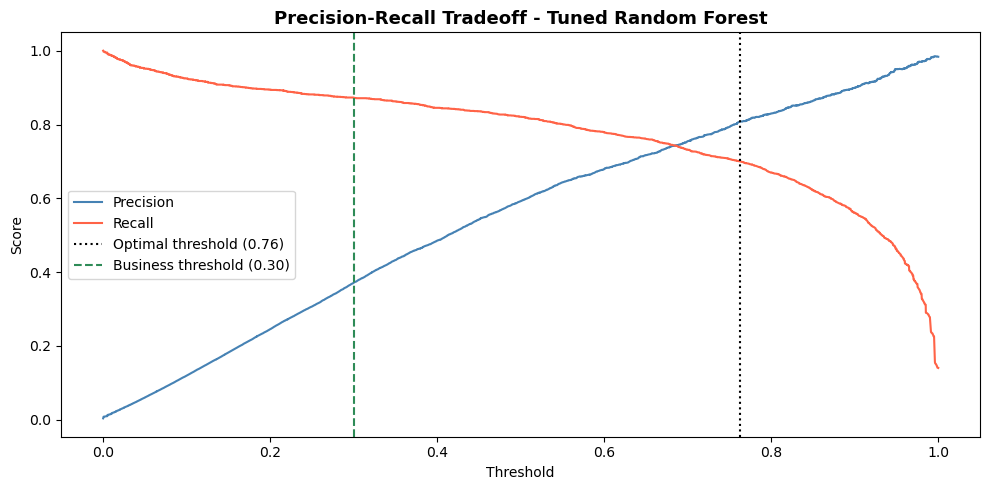

In [43]:
# precision-recall tradeoff plot
plt.figure(figsize=(10, 5))
plt.plot(thresholds, precisions[:-1], label='Precision', color='steelblue')
plt.plot(thresholds, recalls[:-1], label='Recall', color='tomato')
plt.axvline(best_threshold, color='black', linestyle=':', label=f'Optimal threshold ({best_threshold:.2f})')
plt.axvline(0.30, color='seagreen', linestyle='--', label='Business threshold (0.30)')

plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall Tradeoff - Tuned Random Forest', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [44]:
# applying business threshold of 0.30 - prioritize catching fraud (recall) over precision
y_pred_final = (y_proba >= 0.30).astype(int)

print("Final Model (threshold = 0.30):")
print(classification_report(y_test, y_pred_final))

Final Model (threshold = 0.30):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.37      0.87      0.52      2145

    accuracy                           0.99    555719
   macro avg       0.69      0.93      0.76    555719
weighted avg       1.00      0.99      1.00    555719



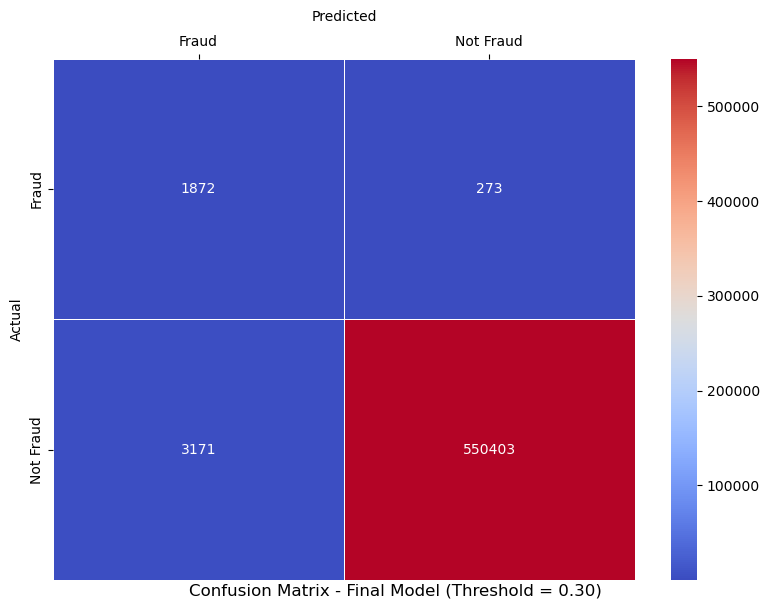

In [45]:
cm_final = confusion_matrix(y_test, y_pred_final, labels=[1, 0])

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_final, cmap='coolwarm', annot=True, fmt='d',
            xticklabels=['Fraud', 'Not Fraud'],
            yticklabels=['Fraud', 'Not Fraud'],
            linewidths=0.5, ax=ax)

ax.xaxis.set_label_position('top')
ax.xaxis.tick_top()
ax.set_xlabel('Predicted', labelpad=10)
ax.set_ylabel('Actual')

fig.text(0.5, 0.00, 'Confusion Matrix - Final Model (Threshold = 0.30)',
         ha='center', fontsize=12)

plt.tight_layout()
plt.show()